In [31]:
import os
print(os.listdir())

['.DS_Store', 'Abuja_Branch.csv', 'Port_Harcourt_Branch.csv', 'combined_sales_data.csv', 'readme.md', 'Lagos_Branch.csv', 'company_xyz.ipynb', '.ipynb_checkpoints']


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [33]:
# Step 1 - Loading Datasets
# Combine all CSV files from different branches
import glob
import pandas as pd

all_files = glob.glob("*.csv")
df_list = [pd.read_csv(file) for file in all_files] # type: ignore
combined_df = pd.concat(df_list, ignore_index=True)
combined_df.to_csv("combined_sales_data.csv", index=False)

In [34]:
combined_df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,692-92-5582,B,Abuja,Member,Female,Food and beverages,19742.4,3,2961.36,62188.56,2/20/2019,13:27,Card,59227.2,4.761905,2961.36,5.9
1,351-62-0822,B,Abuja,Member,Female,Fashion accessories,5212.8,4,1042.56,21893.76,2/6/2019,18:07,Epay,20851.2,4.761905,1042.56,4.5
2,529-56-3974,B,Abuja,Member,Male,Electronic accessories,9183.6,4,1836.72,38571.12,3/9/2019,17:03,Cash,36734.4,4.761905,1836.72,6.8
3,299-46-1805,B,Abuja,Member,Female,Sports and travel,33739.2,6,10121.76,212556.96,1/15/2019,16:19,Cash,202435.2,4.761905,10121.76,4.5
4,319-50-3348,B,Abuja,Normal,Female,Home and lifestyle,14508.0,2,1450.80,30466.80,3/11/2019,15:30,Epay,29016.0,4.761905,1450.80,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,886-18-2897,A,Lagos,Normal,Female,Food and beverages,20361.6,5,5090.40,106898.40,3/22/2019,19:06,Card,101808.0,4.761905,5090.40,4.5
4996,745-74-0715,A,Lagos,Normal,Male,Electronic accessories,20890.8,2,2089.08,43870.68,3/10/2019,20:46,Epay,41781.6,4.761905,2089.08,8.8
4997,727-02-1313,A,Lagos,Member,Male,Food and beverages,11462.4,1,573.12,12035.52,2/9/2019,13:22,Cash,11462.4,4.761905,573.12,7.7
4998,347-56-2442,A,Lagos,Normal,Male,Home and lifestyle,23695.2,1,1184.76,24879.96,2/22/2019,15:33,Cash,23695.2,4.761905,1184.76,4.1


In [35]:
combined_df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,692-92-5582,B,Abuja,Member,Female,Food and beverages,19742.4,3,2961.36,62188.56,2/20/2019,13:27,Card,59227.2,4.761905,2961.36,5.9
1,351-62-0822,B,Abuja,Member,Female,Fashion accessories,5212.8,4,1042.56,21893.76,2/6/2019,18:07,Epay,20851.2,4.761905,1042.56,4.5
2,529-56-3974,B,Abuja,Member,Male,Electronic accessories,9183.6,4,1836.72,38571.12,3/9/2019,17:03,Cash,36734.4,4.761905,1836.72,6.8
3,299-46-1805,B,Abuja,Member,Female,Sports and travel,33739.2,6,10121.76,212556.96,1/15/2019,16:19,Cash,202435.2,4.761905,10121.76,4.5
4,319-50-3348,B,Abuja,Normal,Female,Home and lifestyle,14508.0,2,1450.80,30466.80,3/11/2019,15:30,Epay,29016.0,4.761905,1450.80,4.4


In [36]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               5000 non-null   object 
 1   Branch                   5000 non-null   object 
 2   City                     5000 non-null   object 
 3   Customer type            5000 non-null   object 
 4   Gender                   5000 non-null   object 
 5   Product line             5000 non-null   object 
 6   Unit price               5000 non-null   float64
 7   Quantity                 5000 non-null   int64  
 8   Tax 5%                   5000 non-null   float64
 9   Total                    5000 non-null   float64
 10  Date                     5000 non-null   object 
 11  Time                     5000 non-null   object 
 12  Payment                  5000 non-null   object 
 13  cogs                     5000 non-null   float64
 14  gross margin percentage 

In [37]:
combined_df.describe()
# The statistical summary shows an average unit price of approximately N18,000 with a wide range from N1,500 to N35,000, indicating diverse product pricing. The average quantity purchased is around 5 items per transaction, with a total sales value averaging N300,000, suggesting a robust sales volume. The gross margin percentage is consistently 4.76%, reflecting a uniform profit margin across transactions.

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5.000000e+03,5000.000000,5000.000000
mean,20041.966800,5.510000,5536.572840,116268.029640,110731.45680,4.761905e+00,5536.572840,6.972700
std,9534.249452,2.922261,4213.490428,88483.298978,84269.80855,5.151950e-13,4213.490428,1.717893
min,3628.800000,1.000000,183.060000,3844.260000,3661.20000,4.761905e+00,183.060000,4.000000
25%,11835.000000,3.000000,2132.955000,44792.055000,42659.10000,4.761905e+00,2132.955000,5.500000
50%,19882.800000,5.000000,4351.680000,91385.280000,87033.60000,4.761905e+00,4351.680000,7.000000
75%,28056.600000,8.000000,8080.290000,169686.090000,161605.80000,4.761905e+00,8080.290000,8.500000
max,35985.600000,10.000000,17874.000000,375354.000000,357480.00000,4.761905e+00,17874.000000,10.000000


In [38]:
combined_df.shape

(5000, 17)

In [39]:
combined_df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [40]:
# Step 3 - Dealing with DateTime Features
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
print(combined_df['Date'].dtype)  # Confirm datetime type
combined_df['Time'] = pd.to_datetime(combined_df['Time'], format='%H:%M').dt.time
print(combined_df['Time'].dtype)  # Confirm time type
combined_df['Day'] = combined_df['Date'].dt.day
combined_df['Month'] = combined_df['Date'].dt.month
combined_df['Year'] = combined_df['Date'].dt.year
combined_df['Hour'] = pd.to_datetime(combined_df['Time'].astype(str), format='%H:%M:%S').dt.hour
unique_hours = combined_df['Hour'].unique()
print("Unique sales hours:", unique_hours)

datetime64[ns]
object
Unique sales hours: [13 18 17 16 15 10 12 19 14 11 20]


In [41]:
# Step 4 - Unique Values in Columns
categorical_columns = ['Customer type', 'Gender', 'Product line', 'Payment']
for col in categorical_columns:
    print(f"Unique values in {col}:", combined_df[col].unique())
    print(f"Count of {col} values:\n", combined_df[col].value_counts())

Unique values in Customer type: ['Member' 'Normal']
Count of Customer type values:
 Customer type
Member    2505
Normal    2495
Name: count, dtype: int64
Unique values in Gender: ['Female' 'Male']
Count of Gender values:
 Gender
Female    2505
Male      2495
Name: count, dtype: int64
Unique values in Product line: ['Food and beverages' 'Fashion accessories' 'Electronic accessories'
 'Sports and travel' 'Home and lifestyle' 'Health and beauty']
Count of Product line values:
 Product line
Fashion accessories       890
Food and beverages        870
Electronic accessories    850
Sports and travel         830
Home and lifestyle        800
Health and beauty         760
Name: count, dtype: int64
Unique values in Payment: ['Card' 'Epay' 'Cash']
Count of Payment values:
 Payment
Epay    1725
Cash    1720
Card    1555
Name: count, dtype: int64


In [42]:
# Step 5 - Aggregation with GroupBy
city_group = combined_df.groupby('City').agg({'gross income': ['sum', 'mean'], 'Unit price': 'mean', 'Quantity': 'mean'})
print(city_group)
# Abuja has the highest total gross income with a sum of approximately N6,000,000, indicating it as the most profitable city.

              gross income                 Unit price  Quantity
                       sum         mean          mean      mean
City                                                           
Abuja            9102657.6  5483.528675  20037.339759  5.481928
Lagos            9102888.9  5354.640529  19721.107059  5.467647
Port Harcourt    9477317.7  5778.852256  20379.248780  5.582317


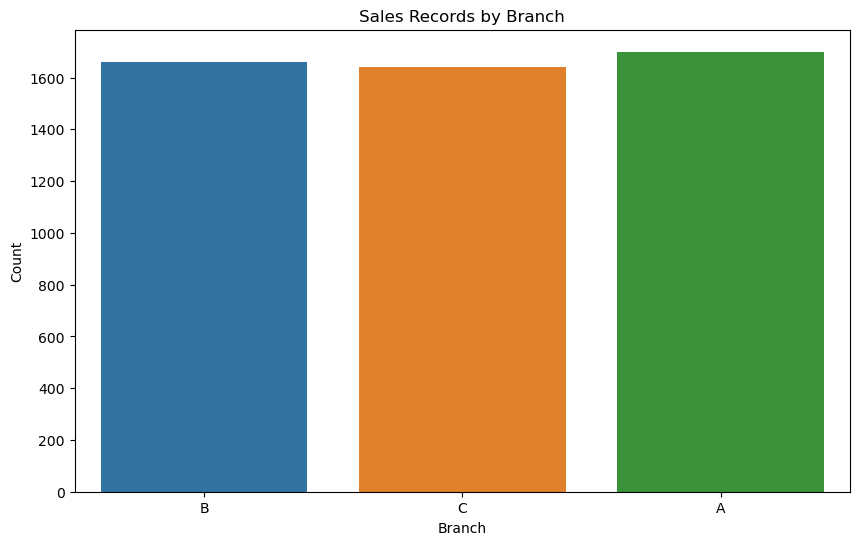

In [43]:
# Step 6 - Data Visualization
plt.figure(figsize=(10, 6))
# Use a custom color palette for distinct colors per bar
sns.countplot(data=combined_df, x='Branch', palette=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Sales Records by Branch')
plt.xlabel('Branch')
plt.ylabel('Count')
plt.show()

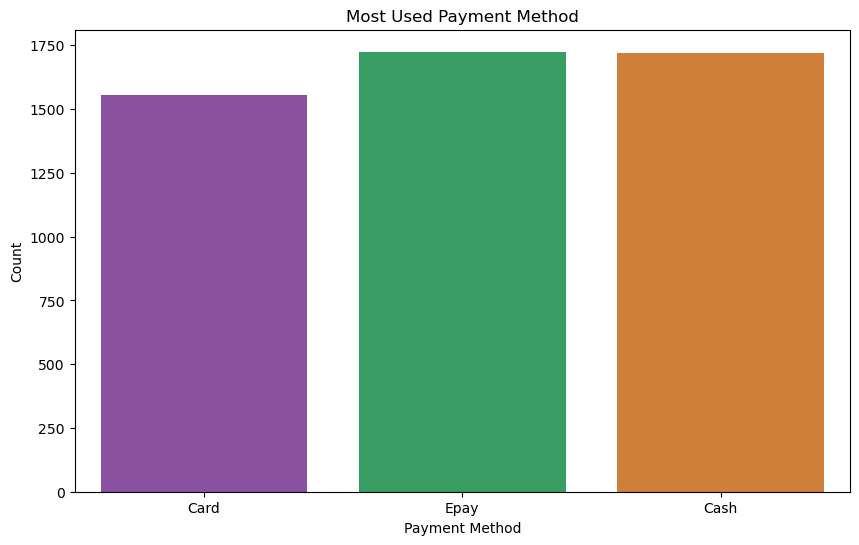

In [44]:
plt.figure(figsize=(10, 6))

# Use a distinct color for each bar
sns.countplot(data=combined_df, x='Payment', palette=['#8e44ad', '#27ae60', '#e67e22'])

plt.title('Most Used Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

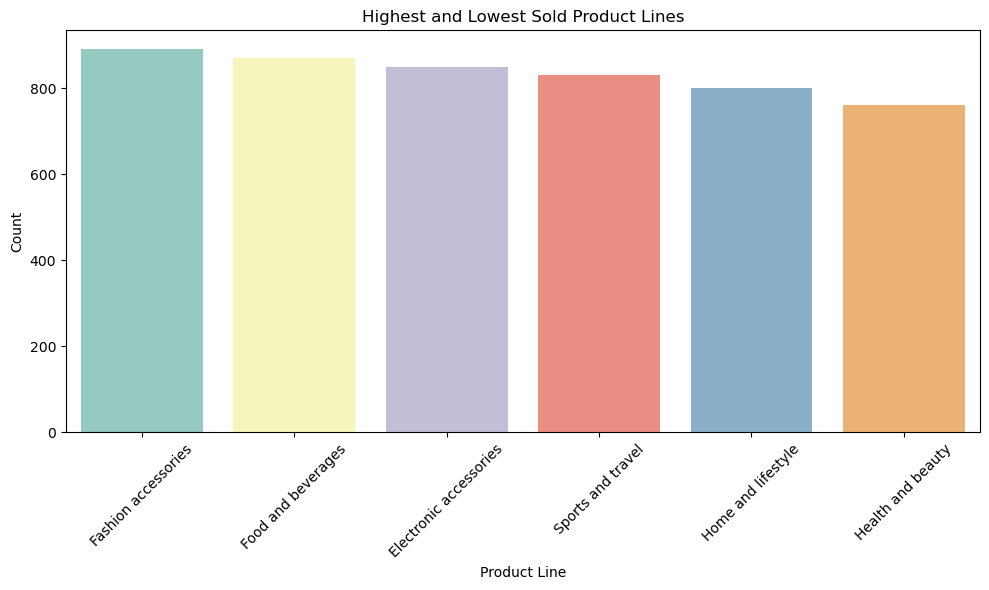

In [45]:
plt.figure(figsize=(10, 6))

# Use a distinct color for each bar using a Seaborn built-in palette
sns.countplot(
    data=combined_df,
    x='Product line',
    order=combined_df['Product line'].value_counts().index,
    palette='Set3'  # You can also try 'tab10', 'Set2', or 'Pastel1'
)

plt.title('Highest and Lowest Sold Product Lines')
plt.xlabel('Product Line')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

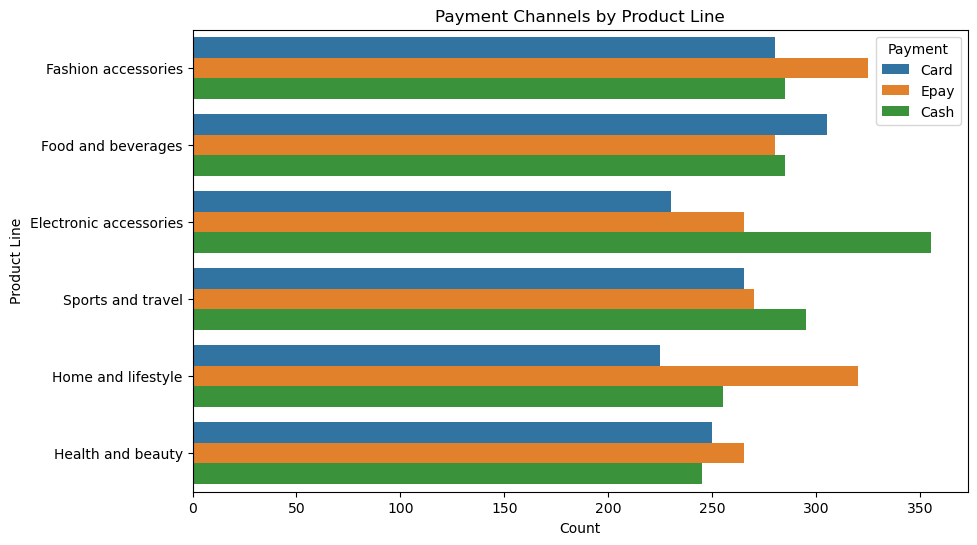

In [46]:
plt.figure(figsize=(10, 6))
sns.countplot(data=combined_df, y='Product line', hue='Payment', order=combined_df['Product line'].value_counts().index)
plt.title('Payment Channels by Product Line')
plt.xlabel('Count')
plt.ylabel('Product Line')
plt.show()

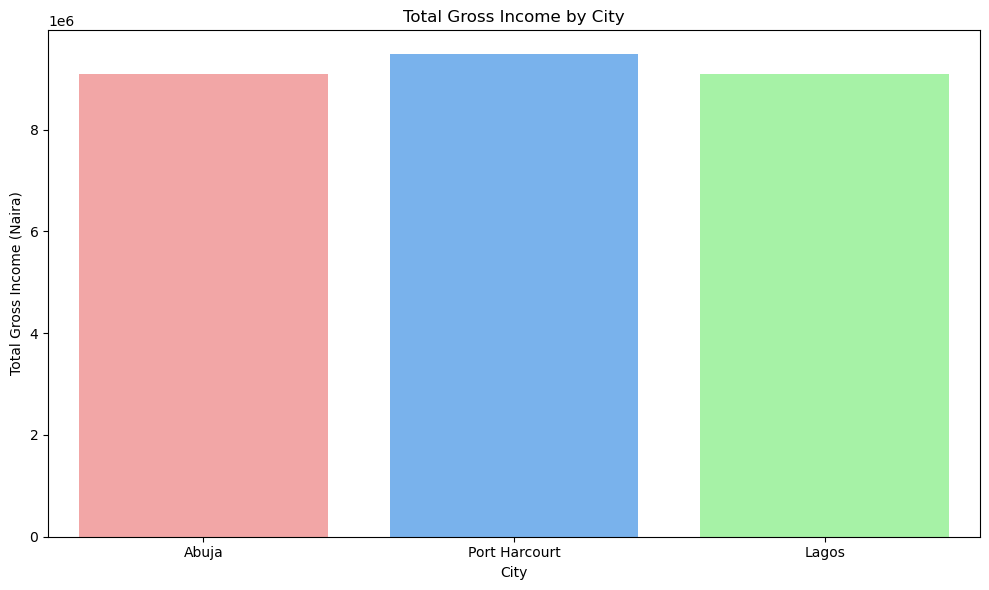

In [47]:
# Define custom colors for each city
city_colors = ['#FF9999', '#66B2FF', '#99FF99']  # Example for 3 cities

plt.figure(figsize=(10, 6))
sns.barplot(
    data=combined_df,
    x='City',
    y='gross income',
    estimator='sum',
    errorbar=None,
    palette=city_colors  # Apply custom colors
)

plt.title('Total Gross Income by City')
plt.xlabel('City')
plt.ylabel('Total Gross Income (Naira)')
plt.tight_layout()
plt.show()

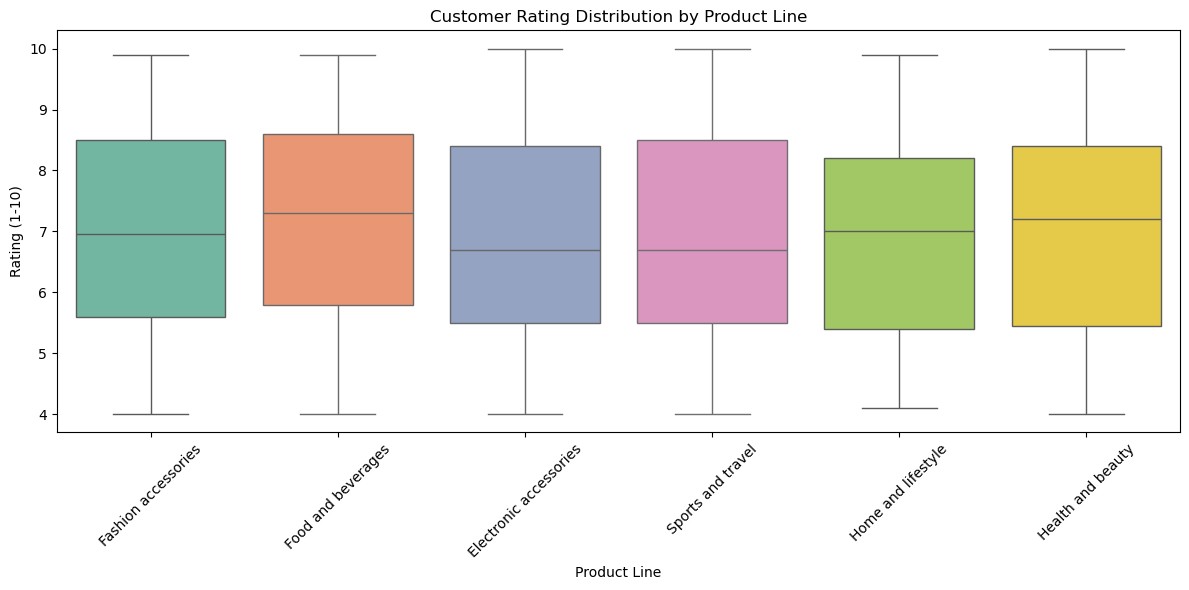

In [48]:
# Get unique product lines in desired order
product_lines = combined_df['Product line'].value_counts().index

# Set custom colors (you can expand this list if needed)
colors = sns.color_palette('Set2', len(product_lines))

plt.figure(figsize=(12, 6))

# Plot each product line individually
for i, product in enumerate(product_lines):
    sns.boxplot(
        data=combined_df[combined_df['Product line'] == product],
        x='Product line',
        y='Rating',
        color=colors[i]
    )

plt.title('Customer Rating Distribution by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Rating (1-10)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

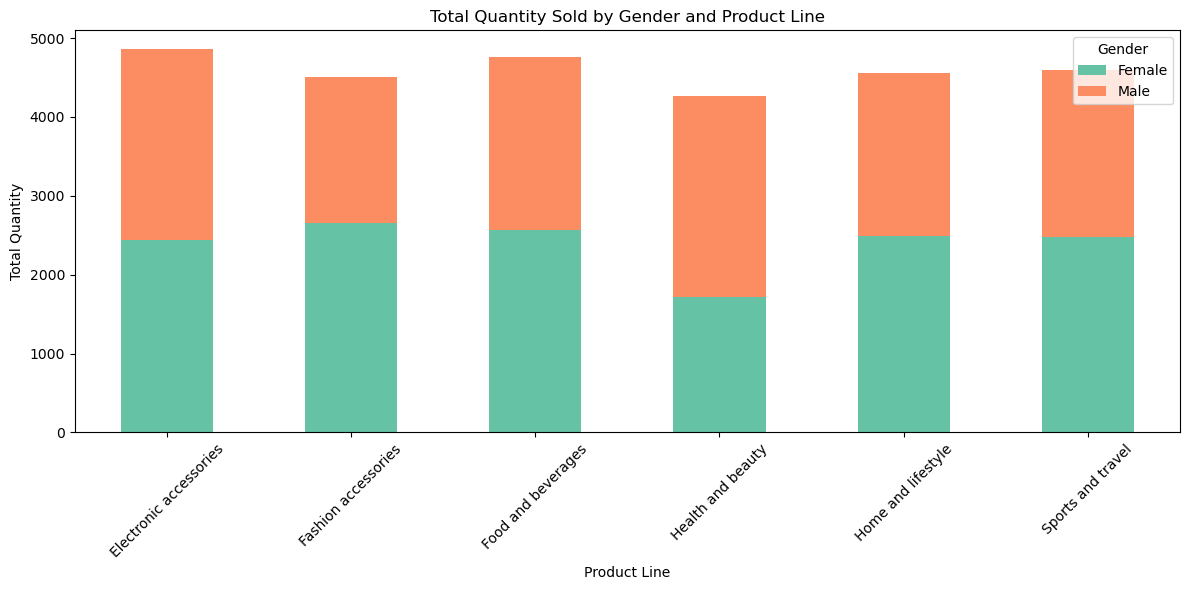

In [49]:
# Pivot the data
pivot_data = combined_df.pivot_table(
    values='Quantity',
    index='Product line',
    columns='Gender',
    aggfunc='sum',
    fill_value=0
)

# Set figure size
plt.figure(figsize=(12, 6))

# Define a color palette for the genders
colors = sns.color_palette("Set2", n_colors=len(pivot_data.columns))

# Plot stacked bar chart with custom colors
pivot_data.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(12, 6)
)

# Add labels and formatting
plt.title('Total Quantity Sold by Gender and Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

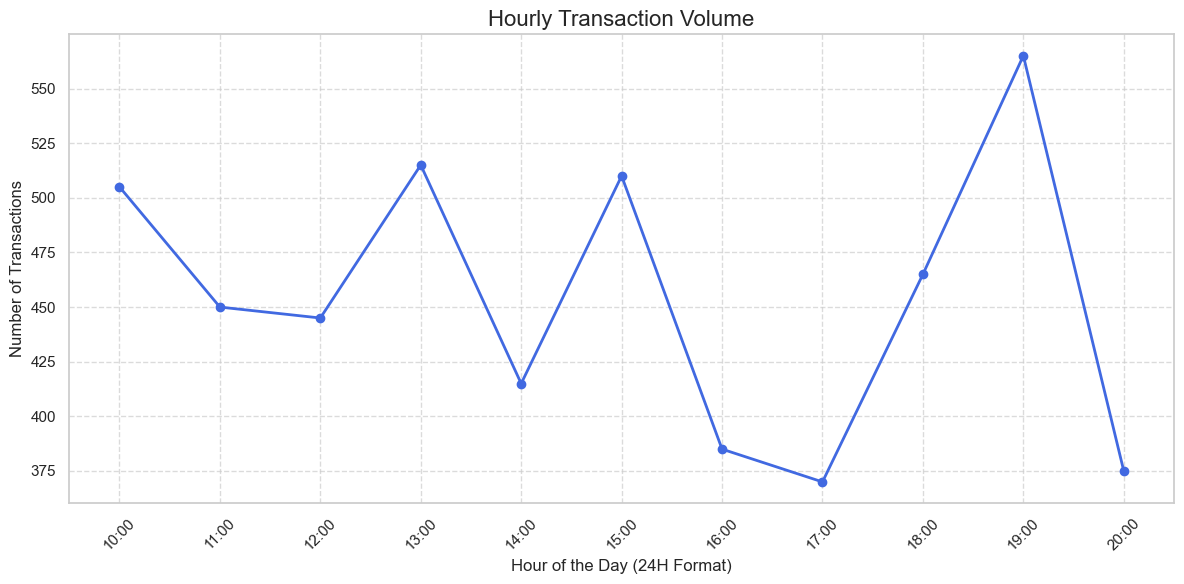

In [50]:
# Set seaborn style
sns.set(style="whitegrid")

# Group data by Hour
hourly_sales = combined_df.groupby('Hour').size()

# Create figure and axis
plt.figure(figsize=(12, 6))
plt.plot(hourly_sales.index, hourly_sales.values, marker='o', linestyle='-', color='royalblue', linewidth=2)

# Title and labels
plt.title('Hourly Transaction Volume', fontsize=16)
plt.xlabel('Hour of the Day (24H Format)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Limit x-axis to store hours (optional)
plt.xticks(hourly_sales.index, [f"{h}:00" for h in hourly_sales.index], rotation=45)

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

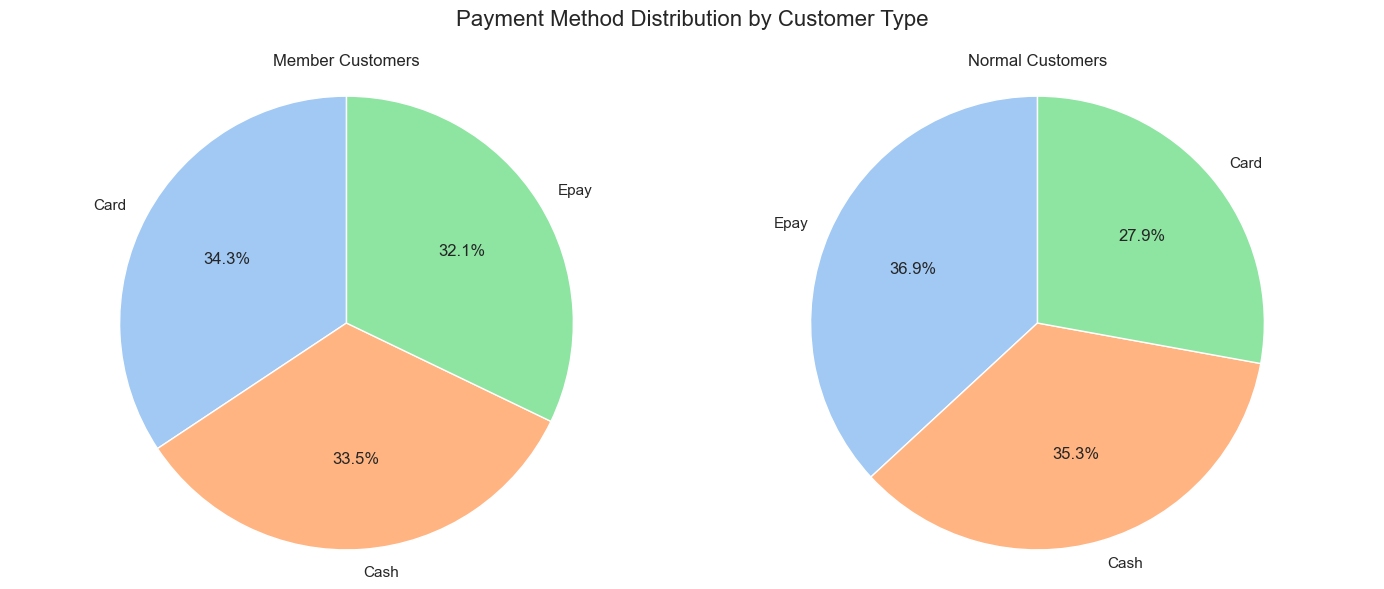

In [51]:
# Set up the figure with subplots — one pie chart per customer type
customer_types = combined_df['Customer type'].unique()
fig, axes = plt.subplots(1, len(customer_types), figsize=(14, 6))

for i, customer_type in enumerate(customer_types):
    subset = combined_df[combined_df['Customer type'] == customer_type]
    payment_counts = subset['Payment'].value_counts()
    
    axes[i].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    axes[i].axis('equal')  # Equal aspect ratio ensures a perfect circle
    axes[i].set_title(f'{customer_type} Customers')

plt.suptitle('Payment Method Distribution by Customer Type', fontsize=16)
plt.tight_layout()
plt.show()


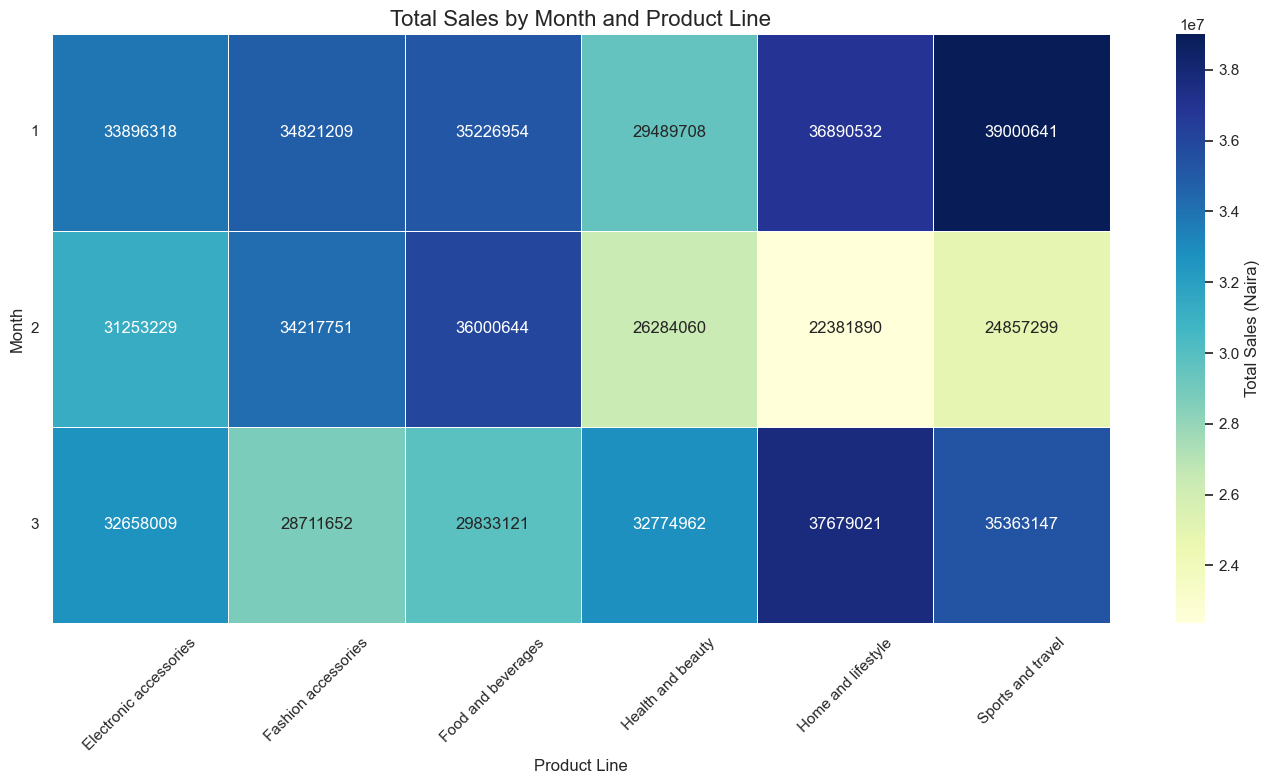

In [52]:
# Create the pivot table for monthly total sales by product line
pivot_table = combined_df.pivot_table(
    values='Total',
    index='Month',
    columns='Product line',
    aggfunc='sum',
    fill_value=0
)

# Set up the figure
plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Total Sales (Naira)'}
)

# Set titles and labels
plt.title('Total Sales by Month and Product Line', fontsize=16)
plt.xlabel('Product Line', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

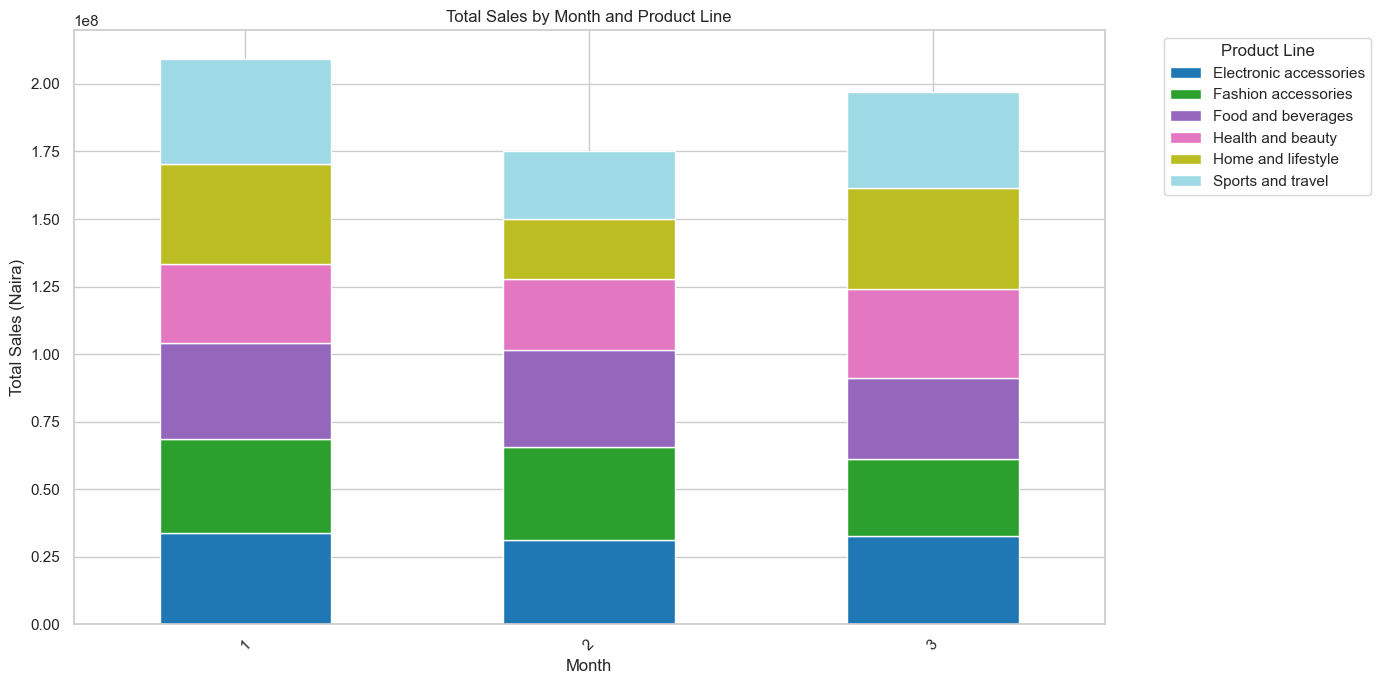

In [53]:
plt.figure(figsize=(12, 6))
month_product_sales = combined_df.pivot_table(
    values='Total',
    index='Month',
    columns='Product line',
    aggfunc='sum',
    fill_value=0
)

month_product_sales.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 7))
plt.title('Total Sales by Month and Product Line')
plt.xlabel('Month')
plt.ylabel('Total Sales (Naira)')
plt.xticks(rotation=45)
plt.legend(title='Product Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

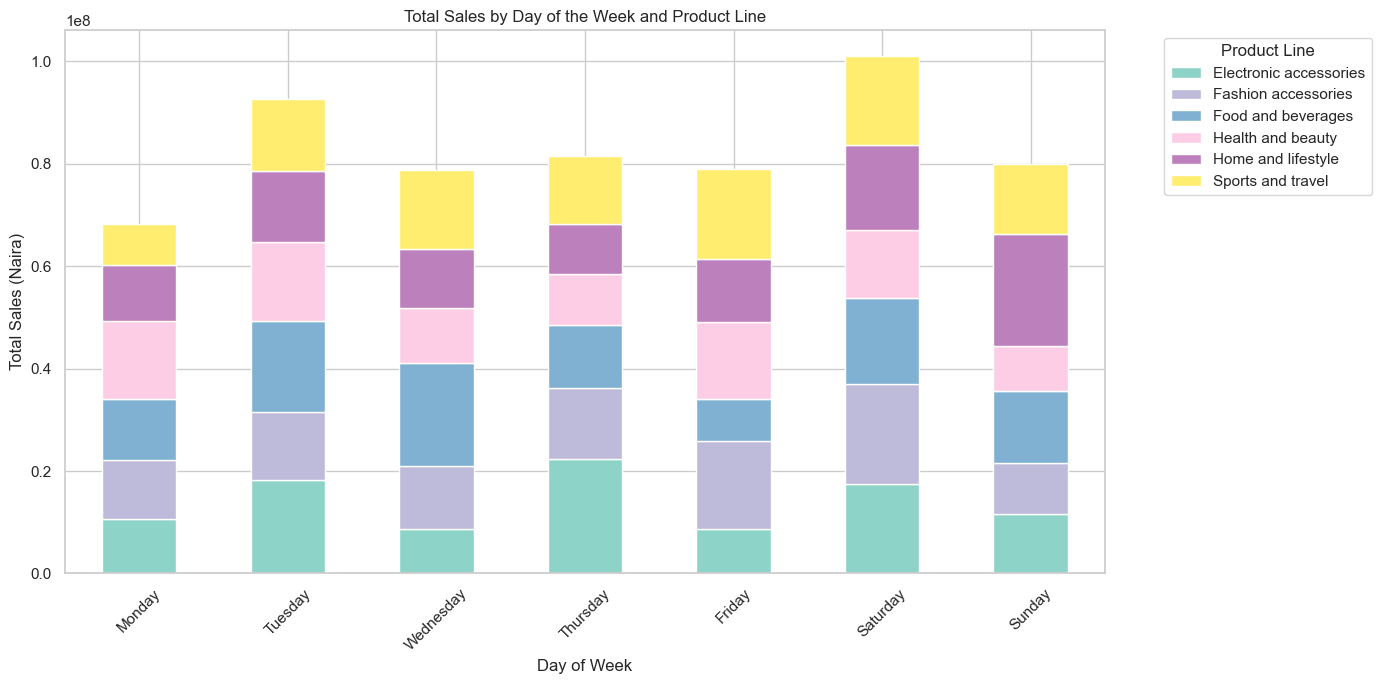

In [54]:
plt.figure(figsize=(12, 6))
combined_df['Day'] = combined_df['Date'].dt.day_name()  # Add day of the week
day_product_sales = combined_df.pivot_table(
    values='Total',
    index='Day',
    columns='Product line',
    aggfunc='sum',
    fill_value=0
)

# Reorder days
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_product_sales = day_product_sales.reindex(ordered_days)

day_product_sales.plot(kind='bar', stacked=True, colormap='Set3', figsize=(14, 7))
plt.title('Total Sales by Day of the Week and Product Line')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales (Naira)')
plt.xticks(rotation=45)
plt.legend(title='Product Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

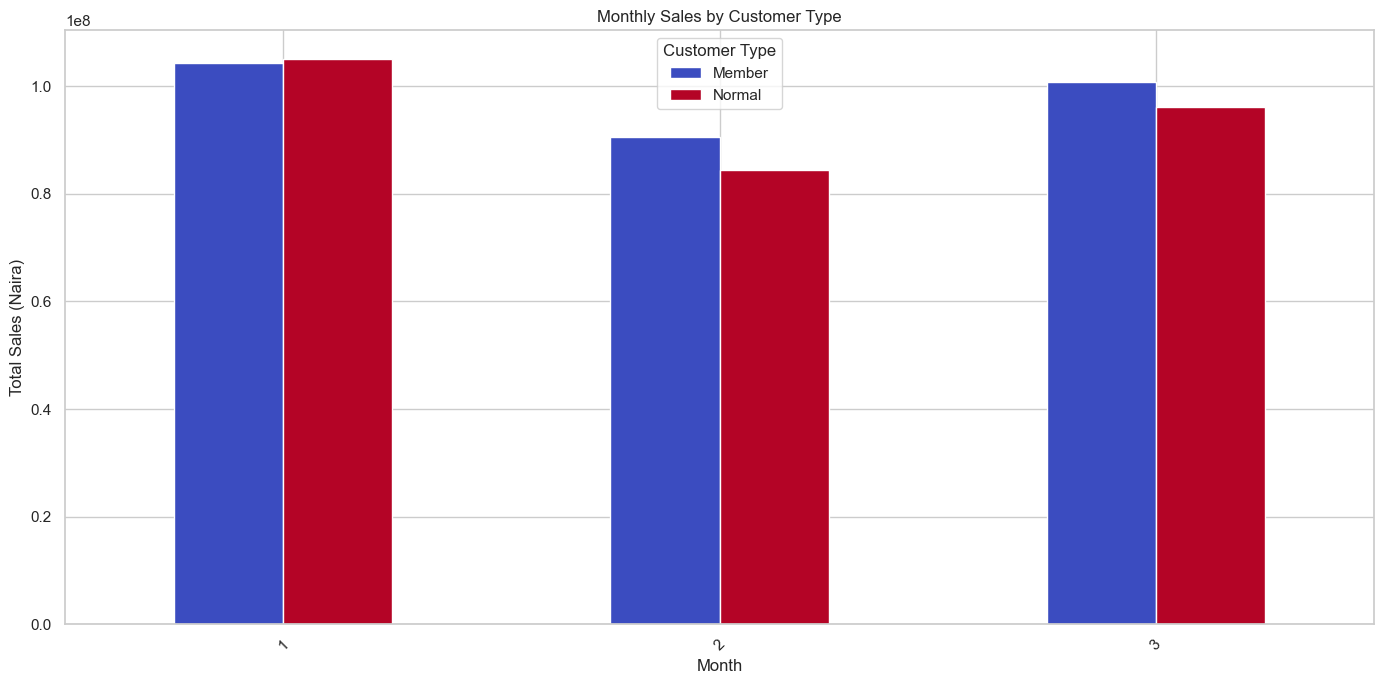

In [55]:
plt.figure(figsize=(12, 6))
month_customer_sales = combined_df.pivot_table(
    values='Total',
    index='Month',
    columns='Customer type',
    aggfunc='sum',
    fill_value=0
)

month_customer_sales.plot(kind='bar', colormap='coolwarm', figsize=(14, 7))
plt.title('Monthly Sales by Customer Type')
plt.xlabel('Month')
plt.ylabel('Total Sales (Naira)')
plt.xticks(rotation=45)
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

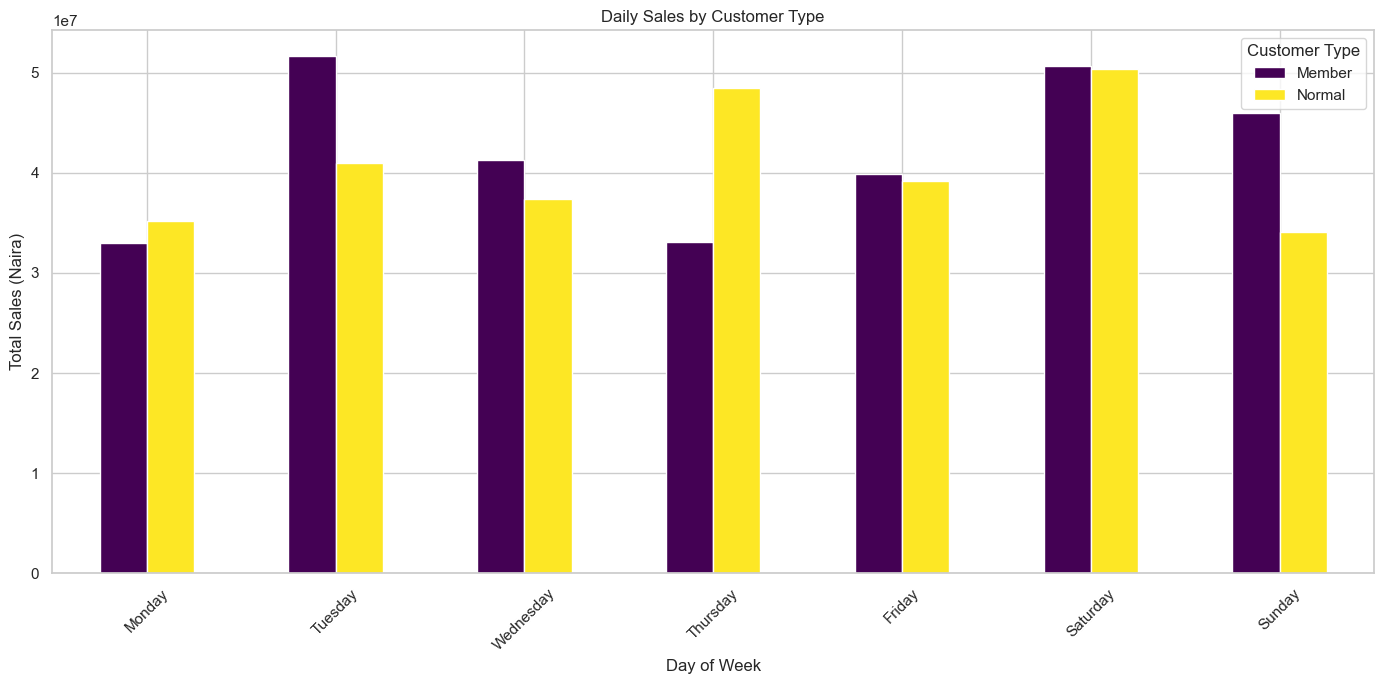

In [56]:
plt.figure(figsize=(12, 6))
day_customer_sales = combined_df.pivot_table(
    values='Total',
    index='Day',
    columns='Customer type',
    aggfunc='sum',
    fill_value=0
)

day_customer_sales = day_customer_sales.reindex(ordered_days)

day_customer_sales.plot(kind='bar', colormap='viridis', figsize=(14, 7))
plt.title('Daily Sales by Customer Type')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales (Naira)')
plt.xticks(rotation=45)
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

In [57]:
!pip install plotly

In [58]:
import plotly.express as px

product_sales = combined_df.groupby('Product line')['Total'].sum().reset_index()

fig = px.bar(product_sales,
             x='Product line',
             y='Total',
             color='Product line',
             title='Total Sales by Product Line',
             labels={'Total': 'Total Sales (Naira)'},
             template='plotly_dark')
fig.update_layout(xaxis_tickangle=45)
fig.show()

In [59]:
month_customer = combined_df.pivot_table(values='Total', index='Month', columns='Customer type', aggfunc='sum').reset_index()

fig = px.bar(month_customer,
             x='Month',
             y=month_customer.columns[1:],  # ['Member', 'Normal']
             barmode='group',
             title='Monthly Sales by Customer Type',
             template='plotly_white')
fig.show()

In [60]:
city_sales = combined_df.groupby('City')['Total'].sum().reset_index()

fig = px.pie(city_sales,
             names='City',
             values='Total',
             title='Sales Distribution by City',
             template='seaborn')
fig.show()


In [61]:
hourly_sales = combined_df.groupby('Hour').size().reset_index(name='Transactions')

fig = px.line(hourly_sales,
              x='Hour',
              y='Transactions',
              markers=True,
              title='Number of Transactions by Hour',
              template='plotly_dark')
fig.update_xaxes(dtick=1)
fig.show()

In [62]:
pivot_data = combined_df.pivot_table(values='Quantity', index='Product line', columns='Gender', aggfunc='sum').reset_index()

fig = px.bar(pivot_data,
             x='Product line',
             y=['Male', 'Female'],
             title='Total Quantity Sold by Gender and Product Line',
             labels={'value': 'Quantity', 'variable': 'Gender'},
             template='plotly_white')
fig.update_layout(barmode='stack', xaxis_tickangle=45)
fig.show()

In [63]:
import plotly.graph_objects as go

pivot_table = combined_df.pivot_table(values='Total', index='Month', columns='Product line', aggfunc='sum', fill_value=0)

fig = go.Figure(data=go.Heatmap(
    z=pivot_table.values,
    x=pivot_table.columns,
    y=pivot_table.index,
    colorscale='YlGnBu'))

fig.update_layout(title='Total Sales by Month and Product Line', xaxis_title='Product Line', yaxis_title='Month')
fig.show()